<font color='blue'><font size="6.9"> The Examples of the Utilization of the CosmPS Code
    
    
<font color='green'><font size="4">Dr. Fei QIN\
CPPM, CNRS/IN2P3, Aix-Marseille University, Marseille, France. \
E-mail:  qin@cppm.in2p3.fr
</font></font>\
(Any bug of the code can be reported to the above email address)

   
\
<font color='brown'><font size="4.9"> Contents </font>
    
    
<font color='brown'>Part 1. The Theoretical Models of the Redshift-Space Galaxy Power Spectrum</font> \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Section 1. Introduction \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Section 2. The Parameters of the Models \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.1. The Parameters \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.2. Some Suggestions About the Choice of the Free Parameters \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Section 3. Calculating the Redshift-Space Power Spectrum Model $P(k,\mu)$ \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.1. The Redshift-Space Power Spectrum Model $P(k,\mu)$  \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.2. Convert the 2D Power Spectrum $P(k,\mu)$ to 1D Power Spectrum $P(k)$ \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Section 4. Calculating the Power Spectrum Multipole Model $P_{\ell}(k )$ \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Section 5. Calculating the Window Function Convolved Power Spectrum Multipole Model $P^c_{\ell}(k )$ 
    
    
<font color='brown'>Part 2. The measurements of the Redshift-Space Galaxy Power Spectrum</font> \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Section 1. The Galaxy Number Density $\bar{n}(\vec{r})$ \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.1. Calculate $\bar{n}(\vec{r})$ in Spherical Shell  \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.2. Calculate $\bar{n}(\vec{r})$ in Cubic Grid \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Section 2. Measuring the Density Power Spectrum  \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Section 3. Measuring the Momentum Power Spectrum \
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Section 4. Measuring the Cross Power Spectrum    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Section 5. Measuring the Power Spectrum of Randoms


<font color='brown'>Part 3. The Window Function Covolution</font>  
 

\
\
<font color='brown'><font size="5.9">Part 1. The Theoretical Models of the Redshift-Space Galaxy Power Spectrum</font></font>

\
<font color='brown'><font size="4.9">Section 1. Introduction</font></font>



In this notebook, we show some examples for the calculations of the redshift-space galaxy power spectrum models. The code of the models are developed based on the perturbation theory of the following papers:\
V12: https://arxiv.org/pdf/1207.0839 \
V13: https://arxiv.org/pdf/1308.6294 \
O14: https://arxiv.org/pdf/1312.4214v2 \
S14: https://arxiv.org/abs/1405.1447 \
H19: https://arxiv.org/pdf/1906.02875 \
Q19: https://arxiv.org/abs/1906.02874 \
Q24: https://arxiv.org/abs/2411.09571 \
Please <font size="4"><font color='red'>cite</font></font> the above papers if you want to use our code to compute the models of galaxy power spectrum. The code can also be downloaded from the GitHub link:   
https://github.com/FeiQin-cosmologist/Galaxy_Power_Spectrum  \
The following Python packages are required for our code:\
1: numpy\
2: scipy\
3: camb \
The 'camb' is used to calculate the real-space linear matter density power spectrum $P_L(k)$. The 'camb' can be downloaded from https://pypi.org/project/camb/ . 

 

The Hubble recessional redshift and peculiar velocity of a galaxy contribute to form its observed redshift. Therefore, the position of a galaxy inferred from its observed redshift is not its true comoving position (real-space possition). Instead, it is a ‘redshift-space’ position contaminated by the peculiar motion. This is the so-called redshift-space distortion (RSD). The spherical symmetry about the line of sight of the power spectrum estimated from the galaxies’ redshift-space positions is broken by RSD. Therefore, a common method is to decompose the redshift-space power spectrum $P(k,\mu)$ using the Legendre polynomials $𝐿_{\ell}(\mu)$, i.e.
$$P(k, \mu)= \sum_{\ell}P_{\ell}(k )L_{\ell}(\mu)$$
where $\ell=0,1,2,3,4,...$. The $k$ is the wave number. The cosine of the angle between the     unit wave vector ${\bf\hat{k}}$ and the line-of-sight unit position vector ${\bf\hat{r}}$ is $\mu={\bf\hat{r}}\cdot {\bf\hat{k}}=\mathrm{cos}\,\theta$. 
The $P_{\ell}(k )$ is the so-called power spectrum multipoles, which is computed from the Legendre transformation of the
redshift-space power pectrum $P(k,\mu)$, i.e.
$$P_l(k)=(2\ell+1) \int^1_0P(k,\mu)L_l(\mu)d\mu$$
In this notebook, we will show how to compute:\
 1: the redshift-space galaxy power spectrum model $P(k,\mu)$; \
 2: the power spectrum multipole model $P_{\ell}(k )$; \
 3: the window function convolved power spectrum multipole model $P^c_{\ell}(k )$. \
We have the auto-density power spectrum $P^{\delta}$, the auto-momentum power spectrum $P^{p}$ and the density-momentum cross-power spectrum $P^{\delta p}$ to compute.
 
\
<font color='brown'><font size="4.9">Section 2. The Parameters of the Models</font></font>

<font color='brown'><font size="3.9">2.1. The Parameters</font></font>

There are, in total, 15 free parameters of the power spectrum models. The keywords of the parameters in the code are:

- <font color='blue'>fsigma8</font>    : $f\sigma_8$ the growth rate. It should be larger than zero, $f\sigma_8\in(0,+\infty)$.     

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<font color='lightpink'> Density field parameters</font> 
- <font color='blue'>b1sigma8</font>   : $b_1\sigma_8$ the first-order biasing parameter of the galaxy density field. It should be larger than zero, $b_1\sigma_8\in(0,+\infty)$.
- <font color='blue'>b2sigma8</font>   : $b_2\sigma_8$ the second-order local biasing parameter of the galaxy density field, and $b_2\sigma_8\in(-\infty,+\infty)$. It can smaller than zero.  
- <font color='blue'>bssigma8</font>   : $b_s\sigma_8$ the second-order nonlocal biasing parameter of the galaxy density field, $b_s\sigma_8\in(-\infty,+\infty)$. It can smaller than zero too. It comes from the tidal tensor. If setting bssigma8='anal' when fitting the models to the measurments, it will be computed using the local Lagrangian relations, rather than treating it as a free parameter. We strongly recommend the users to set bssigma8='anal' when fitting the models. But anyway, it is up to the users.
- <font color='blue'>b3nlsigma8</font> : $b_{3nl}\sigma_8$ the third-order nonlocal biasing parameter of the galaxy density field, $b_{3nl}\sigma_8\in(-\infty,+\infty)$.  If setting b3nlsigma8='anal', it will be computed using the local Lagrangian relations. 
- <font color='blue'>sigmav1_squre</font>   : $\sigma^2_{v1}$ the velocity dispersion parameter of the galaxy density field, correspongding to the loop terms $P_{02}$, $P_{12}$, $P_{22}$ and the vector part of $P_{13}$. It should be larger or euqal than zero, $\sigma^2_{v1}\in[0,+\infty)$. The unit is $km^2/s^2$.
- <font color='blue'>sigmav2_squre</font>   : $\sigma^2_{v2}$ the velocity dispersion parameter of the galaxy density field, correspongding to the loop terms $P_{03}$ and the scalar part of$P_{13}$. $\sigma^2_{v2}\in[0,+\infty)$. The $\ell\ge2$ power spectrum multipole models are sensitive to this parameter. But if the users only want to fit the $\ell=0$ model,  they may want to set its value to be the same as $\sigma^2_{v1}$, i.e. sigmav2_squre=sigmav1_squre. Anyway, it is up to the users. The unit is $km^2/s^2$.
- <font color='blue'>sigmav3_squre</font>   : $\sigma^2_{v3}$ the velocity dispersion parameter of the galaxy density field, correspongding to the loop term $P_{04}$.  $\sigma^2_{v3}\in[0,+\infty)$. The power spectrum models are not sensitive to this parameter, the users may want to set it to be sigmav3_squre=sigmav1_squre too. The unit is $km^2/s^2$. 

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<font color='lightpink'>Momentum field parameters</font>  
- <font color='blue'>b1vsigma8</font>   : $b_{v1}\sigma_8$ the first-order biasing parameter of the galaxy velocity field, and $b_1\sigma_8\in(0,+\infty)$.
- <font color='blue'>b2vsigma8</font>   : $b_{v2}\sigma_8$ the second-order local biasing parameter of the galaxy velocity field, and $b_2\sigma_8\in(-\infty,+\infty)$.  The model of the momentum power spectrum is not sensitive to this parameter, the users can set its value to be the same as the value of the second-order biasing parameter of the density field $b_{2}\sigma_8$, i.e. b2vsigma8=b2sigma8. 
- <font color='blue'>bsvsigma8</font>   : $b_{vs}\sigma_8$ the second-order nonlocal biasing parameter of the velocity field, $b_{vs}\sigma_8\in(-\infty,+\infty)$. If setting bsvsigma8='anal', it will be computed using the local Lagrangian relations. The model of the momentum power spectrum is not sensitive to this parameter, the users can set it to be the same as the density field too, i.e. bsvsigma8=bssigma8 or set it to be bsvsigma8='anal'. 
- <font color='blue'>b3nlvsigma8</font> : $b_{v3nl}\sigma_8$ the third-order nonlocal biasing parameter of the velocity field, $b_{v3nl}\sigma_8\in(-\infty,+\infty)$. If setting b3nlvsigma8='anal', it will be computed using the local Lagrangian relations. The momentum power spectrum model is not sensitive to this parameter, similarly, the users can set it to be b3nlvsigma8=b3nlsigma8 or b3nlvsigma8='anal'. 
- <font color='blue'>sigmavv1_squre</font>   : $\sigma^2_{vv1}$ the velocity dispersion parameter of the velocity field,   $\sigma^2_{vv1}\in[0,+\infty)$. The unit is $km^2/s^2$.
- <font color='blue'>sigmavv2_squre</font>   : $\sigma^2_{vv2}$ the velocity dispersion parameter of the velocity field, $\sigma^2_{vv2}\in[0,+\infty)$. Similarly, the models of the $\ell\ge2$ power spectrum multipoles are sensitive to this parameter. But if the users only want to fit the $\ell=0$ term, they may set it to be sigmavv2_squre=sigmavv1_squre. The unit is $km^2/s^2$.
- <font color='blue'>sigmavv3_squre</font>   : $\sigma^2_{vv3}$ the velocity dispersion parameter of the velocity field, $\sigma^2_{vv3}\in[0,+\infty)$. This parameter is not sensitive in the fit, the users may set it to be sigmavv3_squre=sigmavv1_squre. The unit is $km^2/s^2$.

To compute the auto-density power spectrum model, you only need the fsigma8 and the density field parameters. \
To compute the auto-momentum power spectrum model, you only need the fsigma8 and the momentum field parameters. \
To compute the cross-power spectrum model, all the above 15 parameters are required. 

<font color='brown'><font size="3.9">2.2. Some Suggestions About the Choice of the Free Parameters</font></font>

The power spectrum models are not sensitive to these 15 parameters in a equal level. So, in a practice level, we can reduce some parameters.  

Fitting $P^{\delta}_{0}+P^{p}_{0}$ : \
We can set ($f\sigma_8$,  $b_1\sigma_8$, $b_2\sigma_8$, $\sigma^2_v$) as free parameters. 
In the meanwhile, setting bssigma8='anal', bsvsigma8='anal', b3nlsigma8='anal', b3nlvsigma8='anal'. All the other  biasing parameters of the momentum field are set to be the same as the density field.  Setting all the  velocity dispersion parameters to be the same vale $\sigma^2_v$.  Therefore, we will only have four free parameters to make the models  flexible enought to fit the measurements.
 
Fitting $P^{\delta}_{0}+P^{p}_{0}+P^{\delta p}_{1}$: \
We can set ($f\sigma_8$,  $b_1\sigma_8$, $b_2\sigma_8$, $b_{3nl}\sigma_8$, $\sigma^2_v$) as free parameters. 
In the meanwhile, setting bssigma8='anal', bsvsigma8='anal'. All the other biasing parameters of the momentum field are set to be the same as the density field.  Setting all the  velocity dispersion parameters to be the same vale $\sigma^2_v$.  Therefore, we will only need five free parameters to make the models flexible enought to fit the measurements.

Fitting $P^{\delta}_{02}+P^{p}_{0}+P^{\delta p}_{1}$ : \
We can set ($f\sigma_8$,  $b_1\sigma_8$, $b_2\sigma_8$, $b_{3nl}\sigma_8$, $b_{v1}\sigma_8$, $\sigma^2_{v1}$, $\sigma^2_{v2}$, $\sigma^2_{vv}$) as free parameters. 
In the meanwhile, setting bssigma8='anal', bsvsigma8='anal', b3nlvsigma8='anal'. All the other biasing parameters of the momentum field are set to be the same as the density field. Setting $\sigma^2_{v3}$ of the density field to be sigmav3_squre=sigmav1_squre.  Setting all the  velocity dispersion parameters of the momentum field to be the same vale $\sigma^2_{vv}$.  Therefore, we will have 8 free parameters to make the models flexible enought to fit the measurements. 
 
Fitting $P^{\delta}_{02}+P^{p}_{02}+P^{\delta p}_{1}$ : \
We can set ($f\sigma_8$,  $b_1\sigma_8$, $b_2\sigma_8$, $b_{3nl}\sigma_8$, $b_{v1}\sigma_8$, $b_{v2}\sigma_8$, $\sigma^2_{v1}$, $\sigma^2_{v2}$, $\sigma^2_{vv1}$, $\sigma^2_{vv3}$) as free parameters. 
In the meanwhile, setting b3sigma8='anal', b3vsigma8='anal', sigmav3_squre=sigmav1_squre, b3nlvsigma8='anal', sigmavv2_squre=sigmavv1_squre.  Therefore, we will have 10 free parameters to make the models flexible enought to fit the measurements. 



<font color='red'><font size="3.9">Important Tips:</font></font> \
We strongly recommend the users to set bssigma8='anal' and bsvsigma8='anal' when fittinng the models, rather than setting them as free parameters. \
The choice of the free parameters are completely up to the users. The users should compare the model to their measurements of mocks to figure out that how many parameters are required to make the model flexible enough to reproduce the fiducial  $f\sigma_8$ of the mocks.


<font color='brown'><font size="4.9">Section 3. Calculating the Redshift-Space Power Spectrum Model $P(k,\mu)$</font></font>

<font color='brown'><font size="3.9">3.1. The Redshift-Space Power Spectrum Model $P(k,\mu)$</font></font>

To calculate the redshift-space power spectrum model $P(k,\mu)$, the users can simply copy/paste and run the following 4 lines: 
 
<font color='green'><font size="2">
from PSmodFun import *  \
PT, Sig8_fid, outdir&nbsp;= PSloop_Fun( KmodLim,Hub,ombh2,omch2,ns,As,file_dir) \
Growthz &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;= GrowthFactorGR(RsFeff, OmegaM, OmegaA, 0.,100.,-1.,0.,0.)/GrowthFactorGR(0.0, OmegaM, OmegaA, 0.,100.,-1.,0.,0.) \
k, mu, Pkmu &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;= Pkmod_Fun(parm, Sig8_fid, PT, PS_type, Growthz,False)  
</font></font>
 

where the keyword: \
PS_type = 'den', 'mom' or 'crs' \
for auto-density, auto-momentum or cross- power spectrum, respectively.  


The parameters of the model are encoded in the following order:\
parm = [ fsigma8 ,  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;     b1sigma8 &nbsp;&nbsp;, b2sigma8 &nbsp;&nbsp;, bssigma8&nbsp;&nbsp;, b3nlsigma8 ,  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;      b1vsigma8 , b2vsigma8 , bsvsigma8 , b3nlvsigma8 ,   
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;      sigmav1_squre &nbsp;&nbsp;, sigmav2_squre&nbsp;&nbsp;,  sigmav3_squre ,    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;      sigmavv1_squre , sigmavv2_squre , sigmavv3_squre ]  . \
Therefore, <font color='red'><font size="3">the users need to input the parameters in a correct order as shown in the above</font></font>.       


In the following, we will show the computation of the model power spectrum step by step.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PSmodFun import * # load the module of the model power spectrum  

# This is the directory to store your input and output data. This string should end with '/'.
file_dir = '/Users/fei/WSP/Scie/Proj13/Data/Prod/FP/' #'/global/cfs/cdirs/desi/science/td/pv/PS/Data/Prod/CosmPS/'  

<font color='blue'>Step 1： Calculating the Loop terms: </font>

In [2]:
# The cosmological parameters used to calculate the linear matter power spectrum PL(k) of CAMB.
# They should be the same as the fiducial values of the mocks or simulations you want to use.
# For the abacus_cosm000 simulation and mocks, they are in: 
# https://abacussummit.readthedocs.io/en/latest/cosmologies.html
# or Table.1 and 5 of https://www.aanda.org/articles/aa/pdf/2020/09/aa33910-18.pdf
# The fiducial sigma8_fid_sim =0.811355
OmegaM  = 0.315192
OmegaA  = 1.- OmegaM
Hub     = 67.360# I'm not sure which value should be used for the hubble constant, 67.360 or just using 100. ?????
ombh2   = 0.02237
omch2   = 0.12000
ns      = 0.96490
As      = 2.1011980518085315e-09
# The 'As' parameter is important, users should adjust it to re-produce the fiducial 'sigma8_fid_sim=0.811355' 
# of the mocks by using the following relation:
# 'As = As*sigma8_fid_sim/sigma8_fid_integ'
# where 'sigma8_fid_integ' is the output value on the screen. 
# Adjust 'As' untill 'sigma8_fid_integ' euqals to 'sigma8_fid_sim'.

#The maximume value of k used to compute PL(k).
KmodLim = 1.  # h/Mpc. Yes, this is a very large value for power spectrum.
NKmodbin= 600 # the number of k-bin for PL(k) of camb.

# You only need to calculate the loop terms 'PT' once for a given set of cosmological parameters, 
# and the results will be automatically saved into "  outdir = file_dir+'INTEG_PL.npy' " after the calculation been finished.
# It will take around 1h30mins to make these calculations on NERSC (but only 20mins on MacBook Pro), please be patience.  
PT, Sig8_fid, outdir = PSloop_Fun( KmodLim,NKmodbin,Hub,ombh2,omch2,ns,As,file_dir) 
print('\n The loop terms are saved in:', outdir, '\n')

sigma8_fid_integ =  [0.81135499] 


 Integration-Imn 



/Users/fei/WSP/Scie/Proj13/Prog/FP/PSmodFun.py:60: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integ,errin= sp.integrate.quad(Imn_inner_integ,-1.0,1.0,epsabs=0.0,epsrel=1.0e-4,args=(m,n,k,r,Pl_spline))
/Users/fei/WSP/Scie/Proj13/Prog/FP/PSmodFun.py:60: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  integ,errin= sp.integrate.quad(Imn_inner_integ,-1.0,1.0,epsabs=0.0,epsrel=1.0e-4,args=(m,n,k,r,Pl_spline))
/Users/fei/WSP/Scie/Proj13/Prog/FP/PSmodFun.py:60: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integ,errin= sp.integrate.quad(Imn_inner_integ,-1.0,1.0,epsabs=0.0,epsrel=1.0e-4,args=(m,n,k,r,Pl_spline))
/Users/fei/


 Integration-Jmn 



/Users/fei/WSP/Scie/Proj13/Prog/FP/PSmodFun.py:130: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  J00,errin= sp.integrate.quad(Jmn_integ,kmod[0],kmod[-1],args=(0,0,ks[i],Pl_spline),epsabs=0.0,epsrel=1.0e-3)
/Users/fei/WSP/Scie/Proj13/Prog/FP/PSmodFun.py:132: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from


 Integration-Kmn 


 Integration-Sigma3 


 Integration-norm 


 The loop terms are saved in: /Users/fei/WSP/Scie/Proj13/Data/Prod/FP/INTEG_PL.npy 



<font color='blue'>Step 2： Calculating scale factor $a(z)$ at effective red-shift $z_{eff}$: </font>

In [3]:
RsFeff  = 0.05 # An example effective redshift of a survey. It is not for DESI, it should be updated later for DESI PV. 
Growthz = GrowthFactorGR(RsFeff, OmegaM, OmegaA, 0.0, 100.0, -1.0, 0.0, 0.0)/GrowthFactorGR(0.0, OmegaM, OmegaA, 0.0, 100.0, -1.0, 0.0, 0.0)

<font color='blue'>Step 3： Setting the parameters of power spectrum model: </font>

In [4]:
# Here we just manually set these parameters, they are not fit results from any real surveys.
# growth rate:------------------
fsigma8        = 0.4094
# density field:----------------
b1sigma8       = 1.1257
b2sigma8       = 1.1789
bssigma8       = 'anal'
b3nlsigma8     = -0.4335
sigmav1_squre  = 66.2873
sigmav2_squre  = 156.6696
sigmav3_squre  = sigmav1_squre
# momentum field:---------------
b1vsigma8      = 0.8015
b2vsigma8      = b2sigma8
bsvsigma8      = 'anal' 
b3nlvsigma8    = 'anal'
sigmavv1_squre = 33.8238
sigmavv2_squre = sigmavv1_squre
sigmavv3_squre = sigmavv1_squre
#-------------------------------
# The list of parameters of power spectrum: 
# As mentioned above, the parameters should be listed in the correct order:
parm = [fsigma8  ,  
        b1sigma8 , b2sigma8 , bssigma8 , b3nlsigma8   ,  
        b1vsigma8, b2vsigma8, bsvsigma8, b3nlvsigma8  ,   
        sigmav1_squre , sigmav2_squre  , sigmav3_squre,    
        sigmavv1_squre, sigmavv2_squre , sigmavv3_squre]

<font color='blue'>Step 4： Calculating power spectrum model $P(k,\mu)$: </font>

In [5]:
krsd,mu,Pkmodrsd_den = Pkmod_Fun(parm, Sig8_fid, PT, 'den', Growthz,False) # density  auto-power spectrum. 
krsd,mu,Pkmodrsd_mom = Pkmod_Fun(parm, Sig8_fid, PT, 'mom', Growthz,False) # momentum auto-power spectrum.
krsd,mu,Pkmodrsd_crs = Pkmod_Fun(parm, Sig8_fid, PT, 'crs', Growthz,False) # density-momentum cross-power spectrum.  

In the above, 'krsd' is the wave number $k\in[0,$ KmodLim=$1]$ h/Mpc, 'mu' is the angular $\mu=cos\theta \in[0,1]$. 

The output $P(k,\mu)$, i.e. Pkmodrsd_den, Pkmodrsd_mom and Pkmodrsd_crs are 2D-functions or 2D-images. 

The last keyword '<font color='green'>False</font>' is set to compute $P(k,\mu)$, otherwise, the function 'Pkmod_Fun'  will not return $P(k,\mu)$. So please do not change it. 

Lets make some plots to see how them look like:

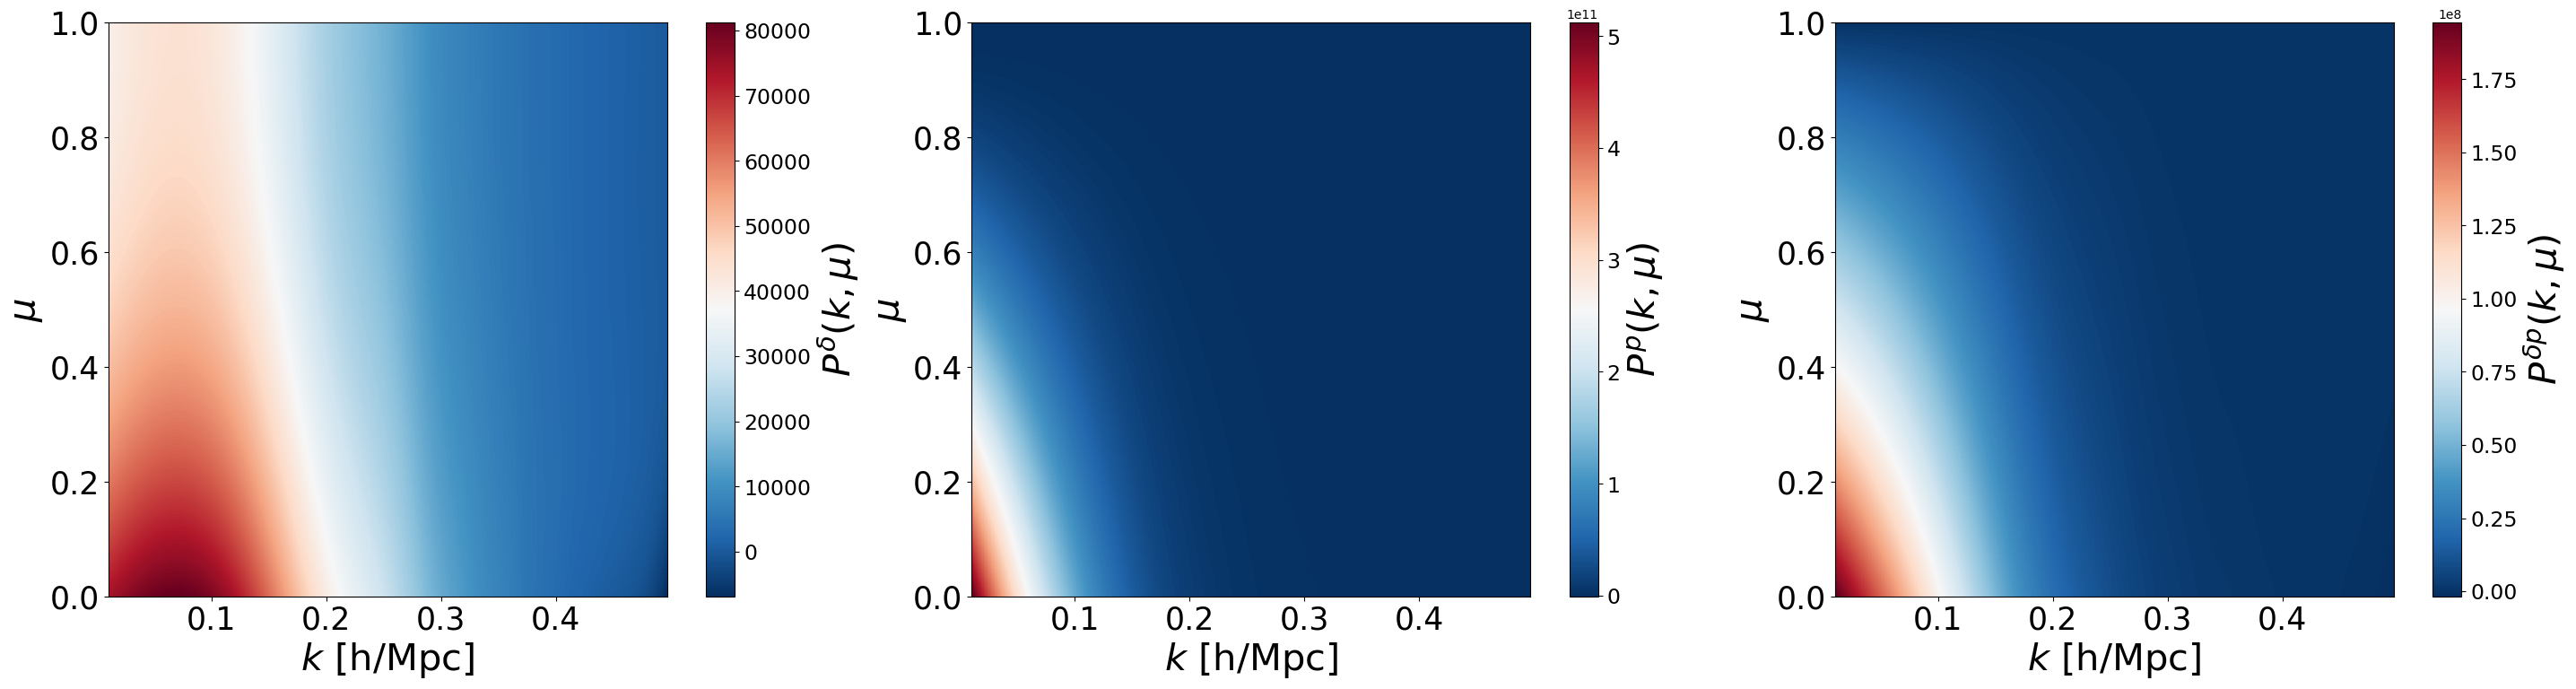

In [6]:
# Please note that kmax = 1 h/Mpc is a supper large value for power spectrum,  
# and k<0.01 h/Mpc is too small for numerical precision,  
# so, we only want to plot the power spectrum in 0.01<k<0.5 :
indk         = np.where((krsd<=0.5)&(krsd>=0.01))[0]
krsd         = krsd[indk]
Pkmodrsd_den = Pkmodrsd_den[indk,:]
Pkmodrsd_mom = Pkmodrsd_mom[indk,:]
Pkmodrsd_crs = Pkmodrsd_crs[indk,:]
# plots:
plt.figure(1,figsize=(32,8))
plt.subplot(131)
im   = plt.imshow( Pkmodrsd_den.T , aspect='0.5',  extent=(np.min(krsd),np.max(krsd),np.min(mu),np.max(mu)), origin='upper',   cmap='RdBu_r', vmin=np.min(Pkmodrsd_den), vmax=np.max(Pkmodrsd_den)  );
cbar = plt.colorbar() ;plt.clim(np.min(Pkmodrsd_den),  np.max(Pkmodrsd_den));cbar.ax.tick_params(labelsize=17); cbar.set_label('$P^{\delta}(k,\mu)$',fontsize=30)  ;plt.ylabel("$\mu$",fontsize=30);plt.xlabel("$k$ [h/Mpc]",fontsize=30); plt.tick_params(axis = 'both', which = 'major', labelsize =25); 
plt.subplot(132)
im   = plt.imshow( Pkmodrsd_mom.T , aspect='0.5',  extent=(np.min(krsd),np.max(krsd),np.min(mu),np.max(mu)), origin='upper',   cmap='RdBu_r', vmin=np.min(Pkmodrsd_mom), vmax=np.max(Pkmodrsd_mom)  );
cbar = plt.colorbar() ;plt.clim(np.min(Pkmodrsd_mom),  np.max(Pkmodrsd_mom));cbar.ax.tick_params(labelsize=17); cbar.set_label('$P^{p}(k,\mu)$',fontsize=30)       ;plt.ylabel("$\mu$",fontsize=30);plt.xlabel("$k$ [h/Mpc]",fontsize=30); plt.tick_params(axis = 'both', which = 'major', labelsize =25); 
plt.subplot(133)
im   = plt.imshow( Pkmodrsd_crs.T , aspect='0.5',  extent=(np.min(krsd),np.max(krsd),np.min(mu),np.max(mu)), origin='upper',   cmap='RdBu_r', vmin=np.min(Pkmodrsd_crs), vmax=np.max(Pkmodrsd_crs)  );
cbar = plt.colorbar() ;plt.clim(np.min(Pkmodrsd_crs),  np.max(Pkmodrsd_crs));cbar.ax.tick_params(labelsize=17); cbar.set_label('$P^{\delta p}(k,\mu)$',fontsize=30);plt.ylabel("$\mu$",fontsize=30);plt.xlabel("$k$ [h/Mpc]",fontsize=30); plt.tick_params(axis = 'both', which = 'major', labelsize =25); 
plt.subplots_adjust(left=0.125,bottom=0.1, right=1.0, top=0.9, wspace=0.1, hspace=0.23)

\
<font color='brown'><font size="3.9">3.2. Convert the 2D Power Spectrum $P(k,\mu)$ to 1D Power Spectrum $P(k)$</font></font>

We can convert the 2D power spectrum $P(k,\mu)$ to 1D power spectrum $P(k)$ by integral $P(k,\mu)$ over $\mu$:
$$P(k)=\int^1_0P(k,\mu)d\mu$$
We can use the Simpson's rule:

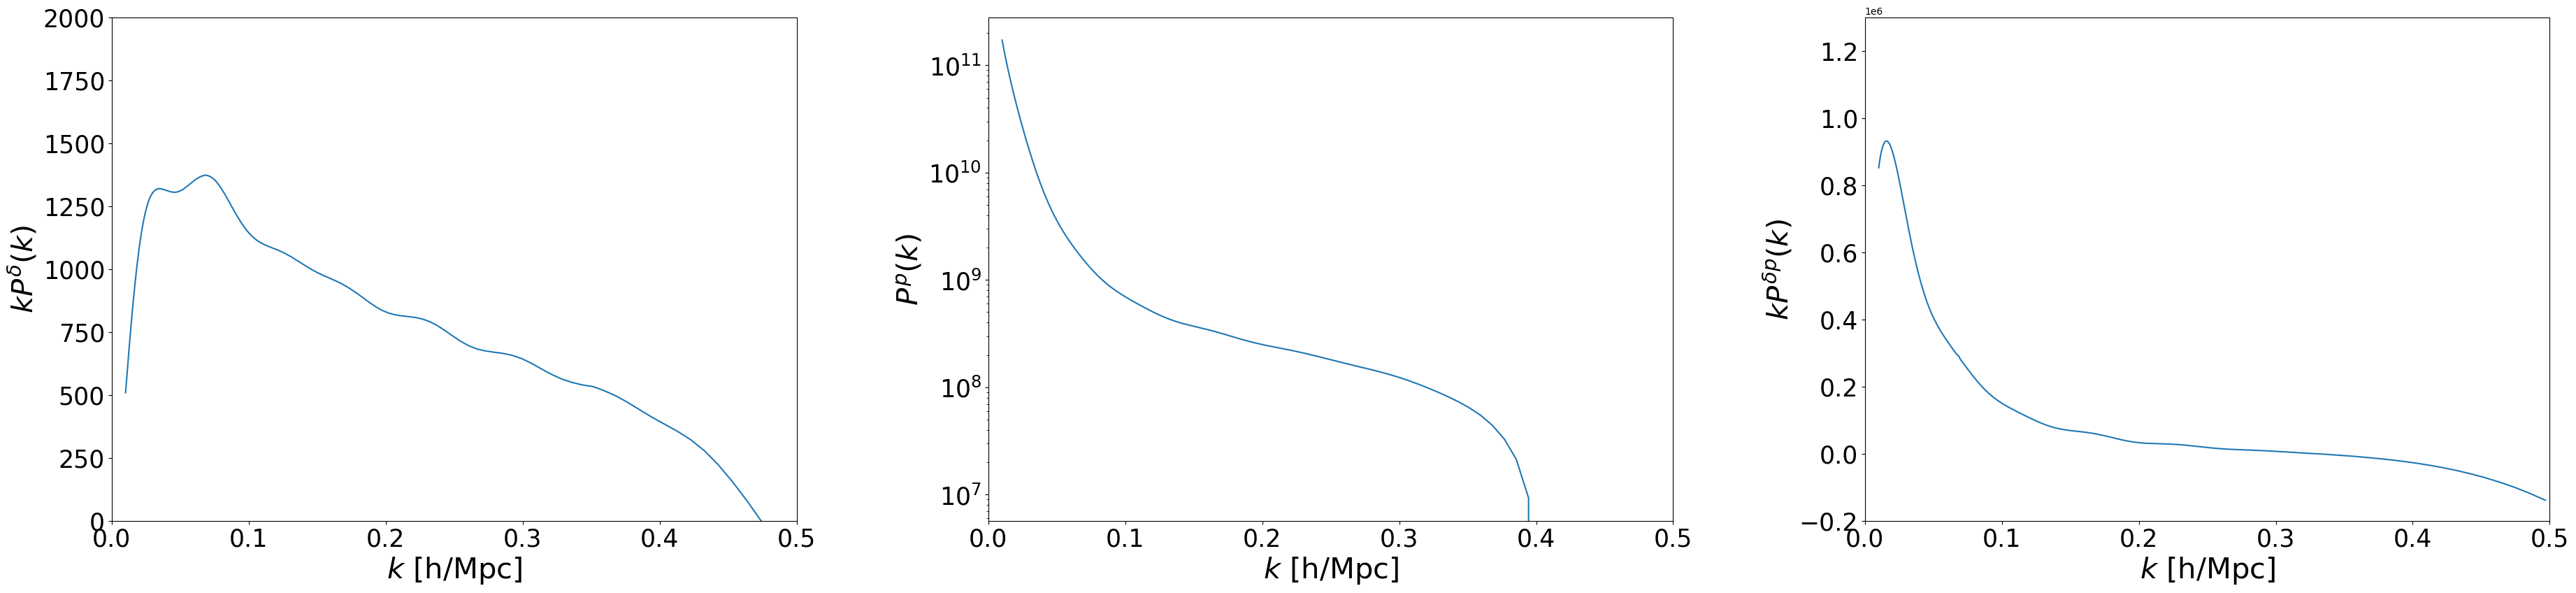

In [7]:
Pk_den = sp.integrate.simps(Pkmodrsd_den,mu,axis=1);
Pk_mom = sp.integrate.simps(Pkmodrsd_mom,mu,axis=1);
Pk_crs = sp.integrate.simps(Pkmodrsd_crs,mu,axis=1);

# make some plots:
plt.figure(2,figsize=(45,9))
plt.subplot(131)
plt.plot(krsd,krsd*Pk_den);plt.ylabel("$kP^{\delta}(k)$",fontsize=30);plt.xlabel("$k$ [h/Mpc]",fontsize=30);plt.tick_params( labelsize =25); plt.xlim(0,0.5); plt.ylim(0,2000)
plt.subplot(132)
plt.yscale('log');plt.plot(krsd, Pk_mom);plt.ylabel("$P^{p}(k)$",fontsize=30);plt.xlabel("$k$ [h/Mpc]",fontsize=30);plt.tick_params( labelsize =25); plt.xlim(0,0.5);  
plt.subplot(133)
plt.plot(krsd, krsd*Pk_crs);plt.ylabel("$kP^{\delta p}(k)$",fontsize=30);plt.xlabel("$k$ [h/Mpc]",fontsize=30);plt.tick_params( labelsize =25); plt.xlim(0,0.5); plt.ylim(-200000,1300000)
plt.subplots_adjust(left=0.125,bottom=0.1, right=0.9, top=0.9, wspace=0.28, hspace=0.23)

\
\
<font color='brown'><font size="4.9">Section 4. Calculating the Power Spectrum Multipole Model $P_{\ell}(k )$</font></font>

To calculate the power spectrum multipole model $P_{\ell}(k )$, the users can simply copy/paste and run the following 4 lines: 

<font color='green'><font size="2">
from PSmodFun import *  \
PT, Sig8_fid, outdir&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;= PSloop_Fun( KmodLim,Hub,ombh2,omch2,ns,As,file_dir) \
Growthz &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;= GrowthFactorGR(RsFeff, OmegaM, OmegaA, 0.,100.,-1.,0.,0.)/GrowthFactorGR(0.0, OmegaM, OmegaA, 0.,100.,-1.,0.,0.) \
Pkmulti ,kmulti, tmp,tmp = PkmodMulti_Fun(parm,False, Sig8_fid, kbin, np.nan,np.nan,np.nan, PT, PS_type, Growthz, np.nan)
</font></font> 

where where the keywords are: 

PS_type = 'den-024', 'mom-024' or 'crs-13' for auto-density, auto-momentum or cross- power spectrum, respectively. 


kbin : the k values the users want to use for the computation of power spectrum.

tmp: cache which is not important, the users can ignore this.

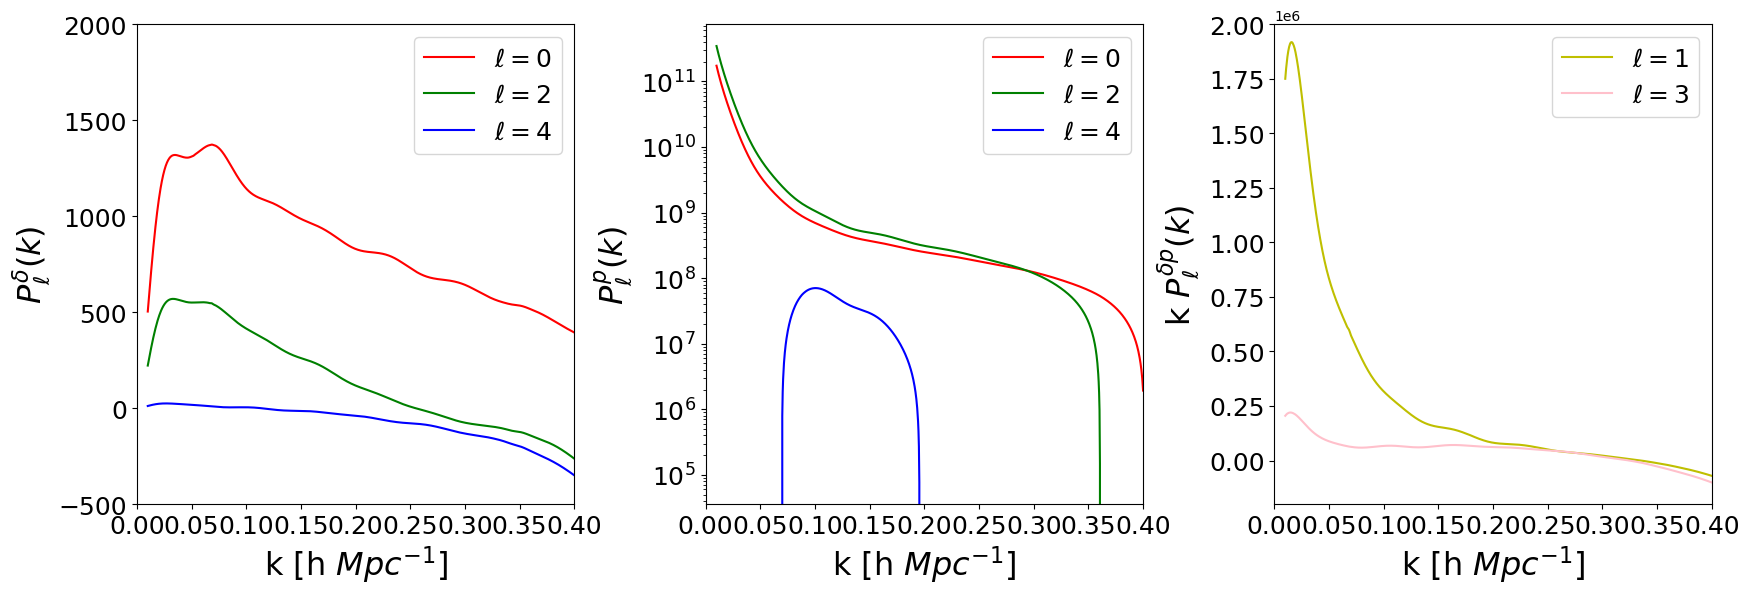

In [8]:
# As mentioned before, we only need to calculate the loop term once, 
# therefore, in here, we directly load the loop terms from file.
sst          = np.load(file_dir+'INTEG_PL.npy',allow_pickle=True)
PT, Sig8_fid = sst  

# set k-bins:
Nk           = 1000
kbin         = np.linspace(0.01,0.4,Nk )

# calculate Power Spectrum Multipole Models:
# density ps:
Pkmulti_den,kmulti_den, tmp,tmp = PkmodMulti_Fun(parm,False, Sig8_fid, kbin, np.nan,np.nan,np.nan, PT, 'den-024', Growthz, np.nan)
# mom ps:
Pkmulti_mom,kmulti_mom, tmp,tmp = PkmodMulti_Fun(parm,False, Sig8_fid, kbin, np.nan,np.nan,np.nan, PT, 'mom-024', Growthz, np.nan)
# crs ps:
Pkmulti_crs,kmulti_crs, tmp,tmp = PkmodMulti_Fun(parm,False, Sig8_fid, kbin, np.nan,np.nan,np.nan, PT, 'crs-13' , Growthz, np.nan) 

#make some plots:
plt.figure(4,figsize=(18,6))
plt.subplot(131)
plt.plot(kmulti_den[0*Nk:1*Nk]  ,kmulti_den[0*Nk:1*Nk] * Pkmulti_den[0*Nk:1*Nk]  ,c='r' ,label='$\ell=0$');
plt.plot(kmulti_den[1*Nk:2*Nk]  ,kmulti_den[1*Nk:2*Nk] * Pkmulti_den[1*Nk:2*Nk]  ,c='g' ,label='$\ell=2$');
plt.plot(kmulti_den[2*Nk:3*Nk]  ,kmulti_den[2*Nk:3*Nk] * Pkmulti_den[2*Nk:3*Nk]  ,c='b' ,label='$\ell=4$');
plt.legend(fontsize=18); plt.xticks(fontsize=18); plt.yticks(fontsize=18); plt.xlim(0,0.4);plt.ylim(-500,2000);
plt.ylabel('$P^{\delta}_{\ell}(k)$',fontsize=23);plt.xlabel('k [h $Mpc^{-1}$]',fontsize=23)
plt.subplot(132)
plt.yscale('log')
plt.plot(kmulti_mom[0*Nk:1*Nk],Pkmulti_mom[0*Nk:1*Nk]  ,c='r',label='$\ell=0$');
plt.plot(kmulti_mom[1*Nk:2*Nk],Pkmulti_mom[1*Nk:2*Nk]  ,c='g',label='$\ell=2$');
plt.plot(kmulti_mom[2*Nk:3*Nk],Pkmulti_mom[2*Nk:3*Nk]  ,c='b',label='$\ell=4$');
plt.legend(fontsize=18);plt.xticks(fontsize=18);plt.yticks(fontsize=18)
plt.ylabel('$P^{p}_{\ell}(k)$',fontsize=23);plt.xlabel('k [h $Mpc^{-1}$]',fontsize=23);plt.xlim(0,0.4)
plt.subplot(133)
plt.plot(kmulti_crs[0*Nk:1*Nk]  ,kmulti_crs[0*Nk:1*Nk] * Pkmulti_crs[0*Nk:1*Nk]  ,c='y' ,label='$\ell=1$');
plt.plot(kmulti_crs[1*Nk:2*Nk]  ,kmulti_crs[1*Nk:2*Nk] * Pkmulti_crs[1*Nk:2*Nk]  ,c='pink' ,label='$\ell=3$');
plt.legend(fontsize=18);plt.xticks(fontsize=18);plt.yticks(fontsize=18)
plt.ylabel('k $P^{\delta p}_{\ell}(k)$',fontsize=23);plt.xlabel('k [h $Mpc^{-1}$]',fontsize=23);plt.xlim(0,0.4);plt.ylim(-0.2*10**6,2*10**6)
plt.subplots_adjust(left=0.125,bottom=0.1, right=1.0, top=0.9, wspace=0.3, hspace=0.23)

\
\
<font color='brown'><font size="4.9">Section 5. Calculating the Window Function Convolved Power Spectrum Multipole Model $P^c_{\ell}(k )$</font></font>

To calculate the window function convolved power spectrum multipole $P^c_{\ell}(k )$, the users can simply copy/paste and run the following 4 lines: 

<font color='green'><font size="2">
from PSmodFun import *  \
PT, Sig8_fid, outdir&nbsp;&nbsp;= PSloop_Fun( KmodLim,Hub,ombh2,omch2,ns,As,file_dir) \
Growthz &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;= GrowthFactorGR(RsFeff, OmegaM, OmegaA, 0.,100.,-1.,0.,0.)/GrowthFactorGR(0.0, OmegaM, OmegaA, 0.,100.,-1.,0.,0.) \
Pkmulti_conv ,kmulti_conv, Pkmulti ,kmulti = PkmodMulti_Fun(parm, OnlyL0, Sig8_fid, kdata , kmod , ConvolutionMatrix,WF_rand, PT, PS_type, ConvolutionMethod )
</font></font> 

where the keywords are: 

PS_type='den-024', 'mom-024' or 'crs-13' for auto-density, auto-momentum or cross- power spectrum, respectively. 

ConvolutionMethod :  'Blake', 'Beutler' or 'Ross' for three different convolution methods. 

OnlyL0 : if using the Ross convolution method, i.e. ConvolutionMethod='Ross', set OnlyL0=True, otherwise, set OnlyL0=False. 

ConvolutionMatrix: the window function convolution matrix.

WF_rand: only for ConvolutionMethod='Ross',  otherwise, set WF_rand=np.nan . 

kdata: the k-bin of the measured power spectrum. 

kmod: the k-bin of the original model power spectrum. 

Pkmulti_conv ,kmulti_conv : the concolved power spectrum model. 

Pkmulti ,kmulti     : the corresponding original power spectrum model. 

The users need the window function convolution matrix for this section. The matrix is computed in other code rather than in this code.

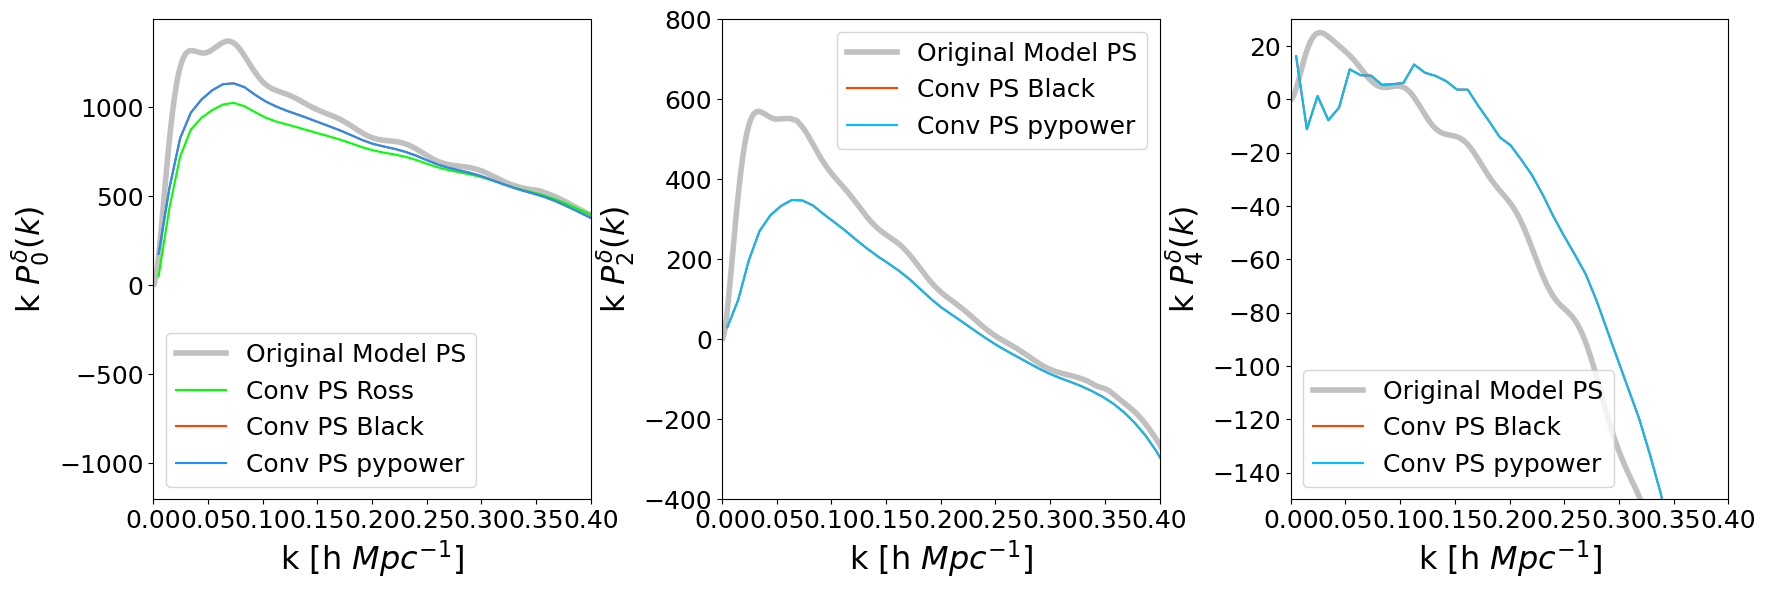

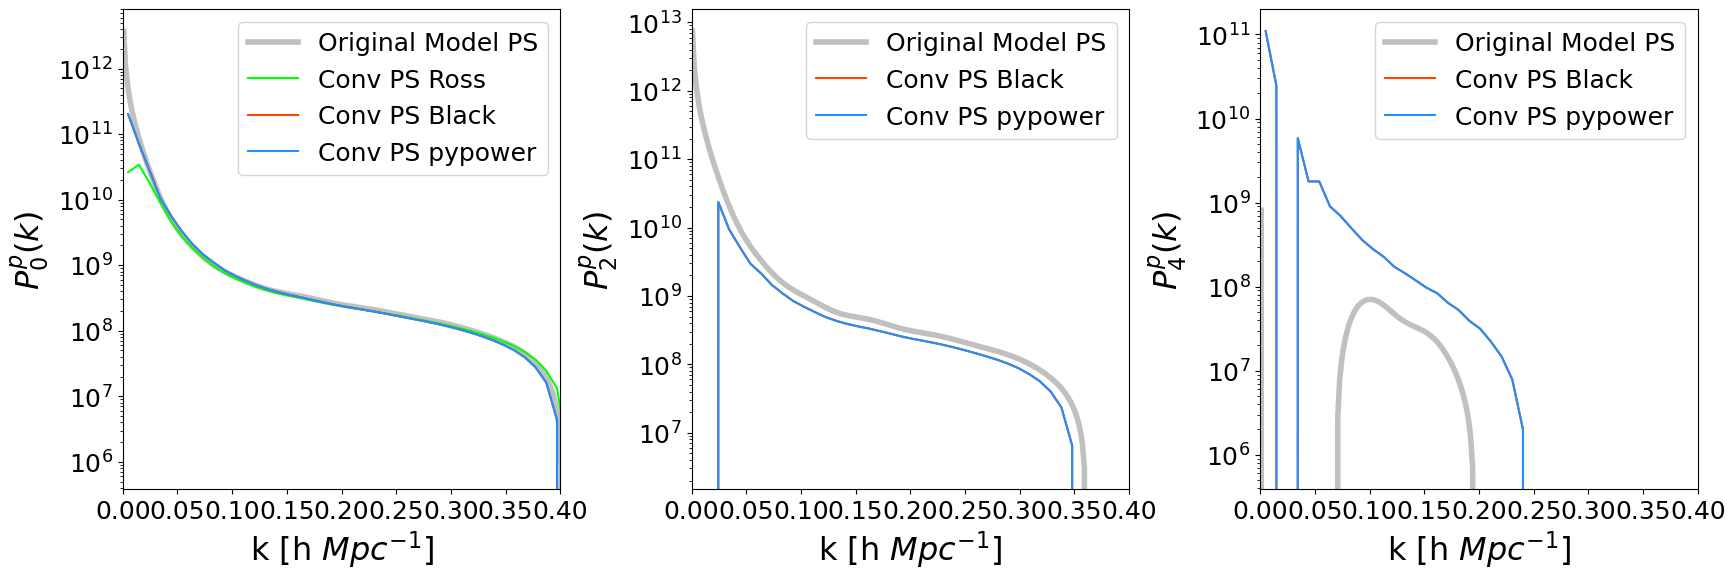

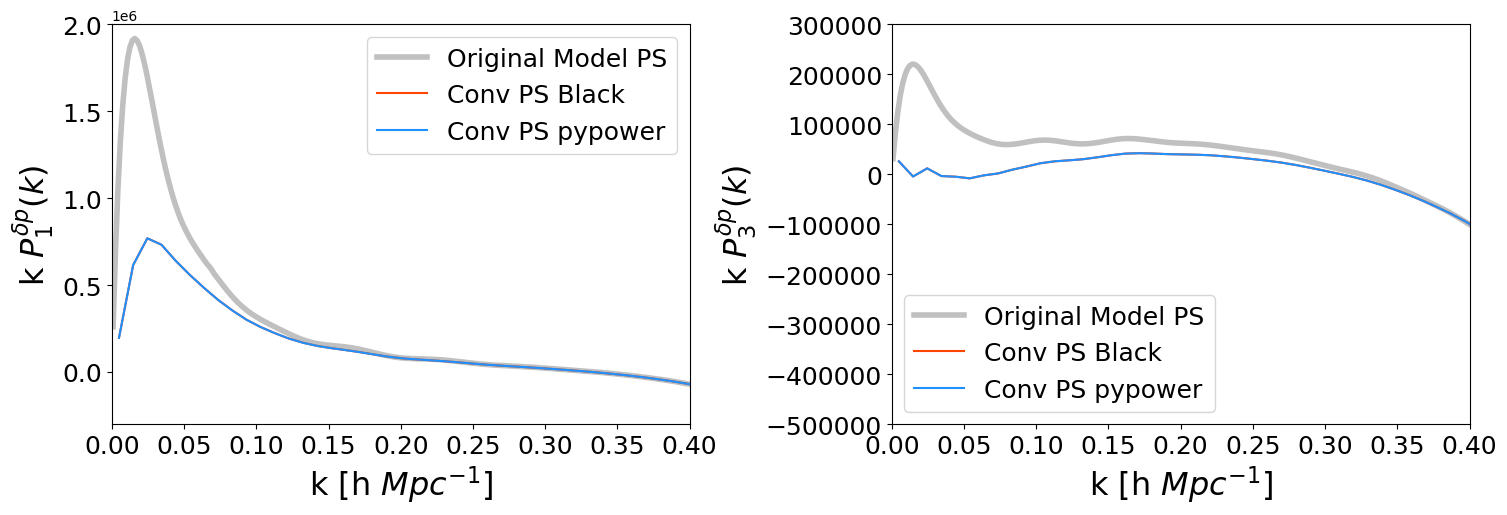

In [9]:
# loading convolution matrix from files, they have been pre-computed: 
# Ross method:
covrossden, k_datar, k_modr, WF_rand = np.load(file_dir+'convden_Ross_mocks.npy',allow_pickle=True) 
covrossmom, k_datar, k_modr, WF_rand = np.load(file_dir+'convmom_Ross_mocks.npy',allow_pickle=True) 
# Blake method:
covden    , kdatab,  kmodb          = np.load(file_dir+'convden_Blake_mocks.npy',allow_pickle=True) 
covmom    , kdatab,  kmodb          = np.load(file_dir+'convmom_Blake_mocks.npy',allow_pickle=True) 
covcrs    , kdatab,  kmodb          = np.load(file_dir+'convcrs_Blake_mocks.npy',allow_pickle=True)
covblack                            = [covden,covmom,covcrs]
Nkmod    = len(kmodb) 
Nkdat    = len(kdatab)
# Pypower: 
covden    , kdatap,  kmodp          = np.load(file_dir+'convden_Beutler_mocks.npy',allow_pickle=True) 
covmom    , kdatap,  kmodp          = np.load(file_dir+'convmom_Beutler_mocks.npy',allow_pickle=True) 
covcrs    , kdatap,  kmodp          = np.load(file_dir+'convcrs_Beutler_mocks.npy',allow_pickle=True)
covpypw                             = [covden,covmom,covcrs]
Nkdatp   = len(kdatap)
# build k-bins: 
k_datab  = np.concatenate(np.array([list(kdatab),list(kdatab),list(kdatab)]))
k_datap  = np.concatenate(np.array([list(kdatap),list(kdatap),list(kdatap)]))
k_modb   =                np.array([list(kmodb) ,list(kmodb) ,list(kmodb)])
k_modp   =                np.array([list(kmodp) ,list(kmodp) ,list(kmodp)])


# calculate the window function convolved power spectrum multipoles:
# density power: 
Pkmodc_denrg,kmodc_denrg,Pkmod_denrg,kmod_denrg = PkmodMulti_Fun(parm,True , Sig8_fid, k_datar , k_modr,  covrossden , WF_rand, PT, 'den-0'  , Growthz, 'Ross' )
Pkmodc_denb ,kmodc_denb ,Pkmod_denb ,kmod_denb  = PkmodMulti_Fun(parm,False, Sig8_fid, k_datab , k_modb,  covblack   , np.nan , PT, 'den-024', Growthz, 'Blake' )
Pkmodc_denp ,kmodc_denp ,Pkmod_denp ,kmod_denp  = PkmodMulti_Fun(parm,False, Sig8_fid, k_datap , k_modp,  covpypw    , np.nan , PT, 'den-024', Growthz, 'Beutler' )
# momentum power: 
Pkmodc_momrg,kmodc_momrg,Pkmod_momrg,kmod_momrg = PkmodMulti_Fun(parm,True , Sig8_fid, k_datar , k_modr,  covrossden , WF_rand, PT, 'mom-0'  , Growthz, 'Ross' )
Pkmodc_momb ,kmodc_momb ,Pkmod_momb ,kmod_momb  = PkmodMulti_Fun(parm,False, Sig8_fid, k_datab , k_modb,  covblack   , np.nan , PT, 'mom-024', Growthz, 'Blake' )
Pkmodc_momp ,kmodc_momp ,Pkmod_momp ,kmod_momp  = PkmodMulti_Fun(parm,False, Sig8_fid, k_datap , k_modp,  covpypw    , np.nan , PT, 'mom-024', Growthz, 'Beutler' )
# cross    power: 
Pkmodc_crsb ,kmodc_crsb ,Pkmod_crsb ,kmod_crsb  = PkmodMulti_Fun(parm,False, Sig8_fid, k_datab , k_modb,  covblack   , np.nan , PT, 'crs-13' , Growthz, 'Blake' )
Pkmodc_crsp ,kmodc_crsp ,Pkmod_crsp ,kmod_crsp  = PkmodMulti_Fun(parm,False, Sig8_fid, k_datap , k_modp,  covpypw    , np.nan , PT, 'crs-13' , Growthz, 'Beutler' )





# make plots:================================================================
plt.figure(5,figsize=(18,6))
plt.subplot(131)
plt.plot(kmod_denb[0*Nkmod:1*Nkmod]   , kmod_denb[0*Nkmod:1*Nkmod]   * Pkmod_denb[0*Nkmod:1*Nkmod]    ,c='silver',lw=4, label='Original Model PS')
plt.plot(kmodc_denrg                  , kmodc_denrg                  * Pkmodc_denrg                   ,c='lime',label='Conv PS Ross')
plt.plot(kmodc_denb[0*Nkdat:1*Nkdat]  , kmodc_denb[0*Nkdat:1*Nkdat]  * Pkmodc_denb[0*Nkdat:1*Nkdat]   ,c='orangered' ,  label='Conv PS Black')
plt.plot(kmodc_denp[0*Nkdatp:1*Nkdatp], kmodc_denp[0*Nkdatp:1*Nkdatp]* Pkmodc_denp[0*Nkdatp:1*Nkdatp] ,c='dodgerblue',label='Conv PS pypower')
plt.legend(fontsize=18);plt.xticks(fontsize=18);plt.yticks(fontsize=18)
plt.ylabel('k $P^{\delta}_{0}(k)$',fontsize=23)
plt.xlabel('k [h $Mpc^{-1}$]',fontsize=23)
plt.xlim(0,0.4);#plt.ylim(0,1500)
plt.subplot(132)
plt.plot(kmod_denb[1*Nkmod:2*Nkmod]    ,kmod_denb[1*Nkmod:2*Nkmod]   * Pkmod_denb[1*Nkmod:2*Nkmod]    ,c='silver',lw=4, label='Original Model PS')
plt.plot(kmodc_denb[1*Nkdat:2*Nkdat]   ,kmodc_denb[1*Nkdat:2*Nkdat]  * Pkmodc_denb[1*Nkdat:2*Nkdat]   ,c='orangered' ,label='Conv PS Black')
plt.plot(kmodc_denp[1*Nkdatp:2*Nkdatp] ,kmodc_denp[1*Nkdatp:2*Nkdatp]* Pkmodc_denp[1*Nkdatp:2*Nkdatp] ,c='deepskyblue',label='Conv PS pypower')
plt.legend(fontsize=18);plt.xticks(fontsize=18);plt.yticks(fontsize=18)
plt.xlim(0,0.4);plt.ylim(-400,800)
plt.ylabel('k $P^{\delta}_{2}(k)$',fontsize=23)
plt.xlabel('k [h $Mpc^{-1}$]',fontsize=23)
plt.subplot(133)
plt.plot(kmod_denb[2*Nkmod:3*Nkmod]    ,kmod_denb[2*Nkmod:3*Nkmod]   * Pkmod_denb[2*Nkmod:3*Nkmod]    ,c='silver',lw=4, label='Original Model PS')
plt.plot(kmodc_denb[2*Nkdat:3*Nkdat]   ,kmodc_denb[2*Nkdat:3*Nkdat]  * Pkmodc_denb[2*Nkdat:3*Nkdat]   ,c='orangered' ,label='Conv PS Black')
plt.plot(kmodc_denp[2*Nkdatp:3*Nkdatp] ,kmodc_denp[2*Nkdatp:3*Nkdatp]* Pkmodc_denp[2*Nkdatp:3*Nkdatp] ,c='deepskyblue',label='Conv PS pypower')
plt.legend(fontsize=18);plt.xticks(fontsize=18);plt.yticks(fontsize=18)
plt.xlim(0,0.4);plt.ylim(-150,30)
plt.ylabel('k $P^{\delta}_{4}(k)$',fontsize=23)
plt.xlabel('k [h $Mpc^{-1}$]',fontsize=23)
plt.subplots_adjust(left=0.125,bottom=0.1, right=1.0, top=0.9, wspace=0.3, hspace=0.23)

plt.figure(6,figsize=(18,6))
plt.subplot(131)
plt.yscale('log')
plt.plot(kmod_momb[0*Nkmod:1*Nkmod]  , Pkmod_momb[0*Nkmod:1*Nkmod]  ,c='silver',lw=4,label='Original Model PS')
plt.plot(kmodc_momrg                 , Pkmodc_momrg                 ,c='lime',label='Conv PS Ross')
plt.plot(kmodc_momb[0*Nkdat:1*Nkdat] , Pkmodc_momb[0*Nkdat:1*Nkdat] ,c='orangered' ,label='Conv PS Black')
plt.plot(kmodc_momp[0*Nkdat:1*Nkdat] , Pkmodc_momp[0*Nkdat:1*Nkdat] ,c='dodgerblue',label='Conv PS pypower')
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel('$P^{p}_{0}(k)$',fontsize=23)
plt.xlabel('k [h $Mpc^{-1}$]',fontsize=23)
plt.xlim(0,0.4)
plt.subplot(132)
plt.yscale('log')
plt.plot(kmod_momb[1*Nkmod:2*Nkmod]  , Pkmod_momb[1*Nkmod:2*Nkmod]  ,c='silver',lw=4,label='Original Model PS')
plt.plot(kmodc_momb[1*Nkdat:2*Nkdat] , Pkmodc_momb[1*Nkdat:2*Nkdat] ,c='orangered' ,label='Conv PS Black')
plt.plot(kmodc_momp[1*Nkdat:2*Nkdat] , Pkmodc_momp[1*Nkdat:2*Nkdat] ,c='dodgerblue',label='Conv PS pypower')
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel('$P^{p}_{2}(k)$',fontsize=23)
plt.xlabel('k [h $Mpc^{-1}$]',fontsize=23)
plt.xlim(0,0.4)
plt.subplot(133)
plt.yscale('log')
plt.plot(kmod_momb[2*Nkmod:3*Nkmod]  , Pkmod_momb[2*Nkmod:3*Nkmod]  ,c='silver',lw=4,label='Original Model PS')
plt.plot(kmodc_momb[2*Nkdat:3*Nkdat] , Pkmodc_momb[2*Nkdat:3*Nkdat] ,c='orangered' ,label='Conv PS Black')
plt.plot(kmodc_momp[2*Nkdat:3*Nkdat] , Pkmodc_momp[2*Nkdat:3*Nkdat] ,c='dodgerblue',label='Conv PS pypower')
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel('$P^{p}_{4}(k)$',fontsize=23)
plt.xlabel('k [h $Mpc^{-1}$]',fontsize=23)
plt.xlim(0,0.4)
plt.subplots_adjust(left=0.125,bottom=0.1, right=1.0, top=0.9, wspace=0.3, hspace=0.23)
 
plt.figure(7,figsize=(9,5))
plt.subplot(131)
plt.plot(kmod_crsb[0*Nkmod:1*Nkmod]  ,kmod_crsb[0*Nkmod:1*Nkmod] * Pkmod_crsb[0*Nkmod:1*Nkmod]  ,c='silver',lw=4,label='Original Model PS')
plt.plot(kmodc_crsb[0*Nkdat:1*Nkdat] ,kmodc_crsb[0*Nkdat:1*Nkdat]* Pkmodc_crsb[0*Nkdat:1*Nkdat] ,c='orangered' ,label='Conv PS Black')
plt.plot(kmodc_crsp[0*Nkdat:1*Nkdat] ,kmodc_crsp[0*Nkdat:1*Nkdat]* Pkmodc_crsp[0*Nkdat:1*Nkdat] ,c='dodgerblue',label='Conv PS pypower')
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel('k $P^{\delta p}_{1}(k)$',fontsize=23)
plt.xlabel('k [h $Mpc^{-1}$]',fontsize=23)
plt.xlim(0,0.4);plt.ylim(-0.3*10**6,2*10**6)
plt.subplot(132)
plt.plot(kmod_crsb[1*Nkmod:2*Nkmod]    ,kmod_crsb[1*Nkmod:2*Nkmod]   * Pkmod_crsb[1*Nkmod:2*Nkmod]  ,c='silver',lw=4,label='Original Model PS')
plt.plot(kmodc_crsb[1*Nkdat:2*Nkdat]   ,kmodc_crsb[1*Nkdat:2*Nkdat]  * Pkmodc_crsb[1*Nkdat:2*Nkdat] ,c='orangered' ,label='Conv PS Black')
plt.plot(kmodc_crsp[1*Nkdatp:2*Nkdatp] ,kmodc_crsp[1*Nkdatp:2*Nkdatp]* Pkmodc_crsp[1*Nkdatp:2*Nkdatp] ,c='dodgerblue',label='Conv PS pypower')
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel('k $P^{\delta p}_{3}(k)$',fontsize=23)
plt.xlabel('k [h $Mpc^{-1}$]',fontsize=23)
plt.xlim(0,0.4);plt.ylim(-0.5*10**6,0.3*10**6)
plt.subplots_adjust(left=0.125,bottom=0.1, right=2.5, top=0.9, wspace=0.35, hspace=0.23)

\
\
<font color='brown'><font size="5.9">Part 2. The measurements of the Redshift-Space Galaxy Power Spectrum</font></font>

\
<font color='brown'><font size="4.9">Section 1. The Galaxy Number Density $\bar{n}(\vec{r})$</font></font>

In [10]:
import numpy as np
from PSestFun import *
from astropy.io import fits
# This is the directory to store your input and output data. This string should end with '/'.
Input_dir       = '/Users/fei/WSP/Scie/Proj13/Data/Orig/'
Output_dir      = '/Users/fei/WSP/Scie/Proj13/Data/Prod/PStest/'

In [11]:
# Read random catalogue: 
with fits.open(Input_dir+'fpgalaxies/Y1/v2/FP_clustering_random_v2.fits') as hfile:
    infiler=hfile[1].data
hfile.close()
ravR     = infiler['RA']
decvR    = infiler['DEC']
zvR      = infiler['Z']  
wvR      = infiler['WEIGHT']
evpR     = logd_to_Vp(infiler['LOGDIST_ERR'],zvR,OmegaM) # convert err_log-dist ratio to velocity error. Watkins et al. 2015.
ndataR   = len(ravR)

The galaxy number density $\bar{n}(\vec{r})$ should be computed from the random catalogue, since $\bar{n}(\vec{r})$ should not have any large-scale-structure infomation and poisson noise. See https://arxiv.org/abs/1910.02914 .
Firstly, calculating $\bar{n}_{R}(\vec{r})$ of the random catalogue, 
than calculating galaxy number density $\bar{n}_{g}(\vec{r})$ for each galay using $\bar{n}_{R}(\vec{r})$. 

In [12]:
# Read data catalogue:
with fits.open(Input_dir+'fpgalaxies/Y1/v2/FP_clustering_data_v2.fits') as hfile:
            infile=hfile[1].data
hfile.close()
rav      = infile['RA'] 
decv     = infile['DEC']
zv       = infile['Z'] 
logd     = infile['LOGDIST'] 
elogd    = infile['LOGDIST_ERR'] 
wv       = infile['WEIGHT']
vp       = logd_to_Vp(logd,zv,OmegaM) # convert log-dist ratio to velocity. watkins2015 estimator. 
evp      = zv*LightSpeed/(1.+zv)*np.log(10.)*elogd 
ndata    = len(rav)

<font color='brown'><font size="3.9">1.1 Calculate $\bar{n}(\vec{r})$ in Spherical Shell  </font></font>

/Users/fei/anaconda3/lib/python3.11/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/fei/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


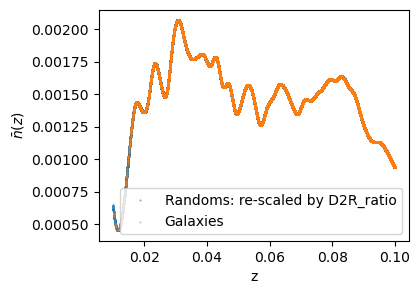

In [13]:
# setting cosmological and shell parameters: 
OmegaM = 0.3151
OmegaA = 1.-OmegaM
Hub    = 100.
delt_z = 0.002 # shell thickness
SurveyArea = 4*np.pi * 0.5 # this is a 'fake' value of the sky coverage area of the galaxy survey. 
                           # The users need to calculate this value by themselves. 

# calculating nbar of the random catalogue:
nbR_S = nbarS_Fun(delt_z,zvR,wvR,SurveyArea,OmegaM,OmegaA,Hub)
# calculating the number ratio between the random catalogue and galaxy catalogue:
D2R_ratio = ndata/ndataR
# calculating nbar of the galaxies:
nb_S  = nbarSAsign_Fun( zv,zvR,     nbR_S     * D2R_ratio   ) 

# make some plots:
plt.figure(8,figsize=(4,3))
plt.scatter(zvR,nbR_S*D2R_ratio,s=0.1,label='Randoms: re-scaled by D2R_ratio');
plt.scatter(zv,nb_S,s=0.1,label='Galaxies');
plt.legend(fontsize=10)
plt.ylabel(r"$\bar{n}(z)$",fontsize=10);plt.xlabel("z",fontsize=10);plt.tick_params( labelsize =10); 

<font color='brown'><font size="3.9">1.2 Calculate $\bar{n}(\vec{r})$ in Cubic Grid </font></font>

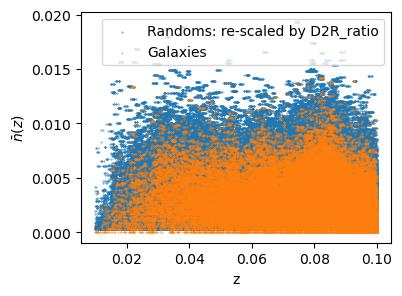

In [14]:
# setting cosmological and grid parameters: 
OmegaM = 0.3151
OmegaA = 1.-OmegaM
Hub    = 100.
nbx,nby,nbz = 128,128,128

# calculating nbar of the random catalogue:
nbR,NgridDenR,Xlim,Ylim,Zlim = nbarG_Fun(ravR,decvR,zvR,wvR,nbx,nby,nbz,OmegaM,OmegaA,Hub)
# calculating the number ratio between the random catalogue and galaxy catalogue:
D2R_ratio = ndata/ndataR
# calculating nbar of the galaxies:
nb   = nbarGAsign_Fun( rav,decv,zv,  NgridDenR * D2R_ratio  ,Xlim,Ylim,Zlim,  OmegaM,OmegaA,Hub) 

# make some plots:
plt.figure(9,figsize=(4,3))
plt.scatter(zvR,nbR*D2R_ratio,s=0.1,label='Randoms: re-scaled by D2R_ratio');
plt.scatter(zv,nb,s=0.1,label='Galaxies');
plt.legend(fontsize=10)
plt.ylabel(r"$\bar{n}(z)$",fontsize=10);plt.xlabel("z",fontsize=10);plt.tick_params( labelsize =10); 

<font color='brown'><font size="4.9">Section 2. Measuring the Density Power Spectrum  </font></font>

  Please make sure that in the catalogue, observer is at Coordinate origin=[0,0,0] 

  den   Ngal= 73547
 


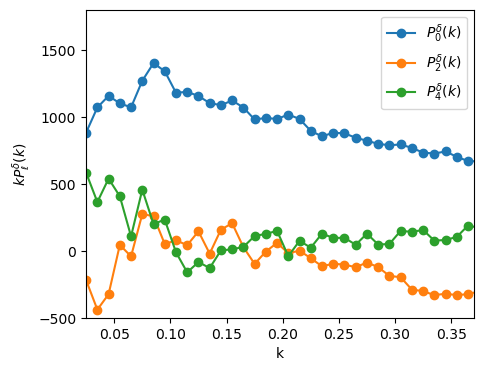

In [15]:
# fiducial cosmological parameters: 
OmegaM          = 0.3151
OmegaA          = 1.-OmegaM
Hub             = 100.
sigv            = 300.0
# power spectrum parameters
FKP             = 1600.
FKPv            = 5.*10.**9
PS_multi        ='all'  #  'no' # 'yes' 
# grid and k-bin for mocks and data:
kmin,kmax,nk    = 0.0,0.4,40
nx,ny,nz        = 400,400,400 
xmin,xmax       = -400. ,400. 
ymin,ymax       = -400. ,400.
zmin,zmax       = -400. ,400. 
# Observer's bulk velocity:
Bulk_vel        = np.array([0.,0.,0.])

# density power spectrum: 
out_dir,wfkp, Norm  = Pkest_Fun(kmin,kmax,nk,nx,ny,nz,xmin,xmax,ymin,ymax,zmin,zmax,
                                            rav,decv,zv,nb,FKP,ravR,decvR,zvR,nbR*D2R_ratio,
                                            np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,
                                            OmegaM,OmegaA,Hub,sigv, 
                                            np.nan,'den',PS_multi,Output_dir+'ExampData_den',
                                            wv,wvR)# wv,wvR are weights of galaxies and randoms, you can set them to be '1'.

# make some plots:
psfile=np.loadtxt(Output_dir+'ExampData_den');
k =psfile[:,1] ; p0=psfile[:,2] ; p2=psfile[:,4] ; p4=psfile[:,6]
plt.figure(9,figsize=(5,4))
plt.plot(k,k*p0,marker='o',label='$P^{\delta}_0(k)$'); 
plt.plot(k,k*p2,marker='o',label='$P^{\delta}_2(k)$');
plt.plot(k,k*p4,marker='o',label='$P^{\delta}_4(k)$');
plt.xlim(0.025,0.37);plt.ylim(-500,1800);plt.legend(fontsize=10)
plt.legend(fontsize=10)
plt.ylabel(r"$kP^{\delta}_{\ell}(k)$",fontsize=10);plt.xlabel("k",fontsize=10);plt.tick_params( labelsize =10); 

<font color='brown'><font size="4.9">Section 3. Measuring the Momentum Power Spectrum </font></font>

  Please make sure that in the catalogue, observer is at Coordinate origin=[0,0,0] 

  mom   Npv = 73547
 


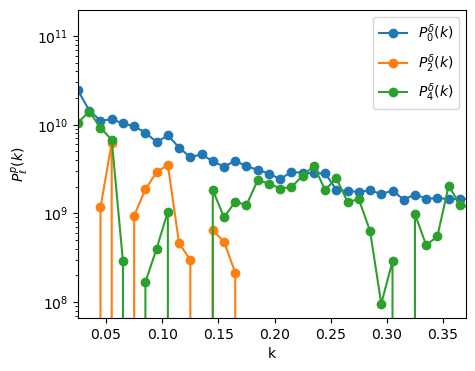

In [16]:
out_dir,wfkpv, Normv = Pkest_Fun(kmin,kmax,nk,nx,ny,nz,xmin,xmax,ymin,ymax,zmin,zmax,
                                             np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,
                                             rav,decv,zv,vp,evp,nb,FKPv,
                                             OmegaM,OmegaA,Hub,sigv,
                                             Bulk_vel,'mom',PS_multi,Output_dir+'ExampData_mom',
                                             np.nan,np.nan,wv) 
# make some plots:
psfile=np.loadtxt(Output_dir+'ExampData_mom');
k =psfile[:,1] ; p0=psfile[:,2] ; p2=psfile[:,4] ; p4=psfile[:,6]
plt.figure(9,figsize=(5,4))
plt.yscale('log')
plt.plot(k,p0,marker='o',label='$P^{\delta}_0(k)$'); 
plt.plot(k,p2,marker='o',label='$P^{\delta}_2(k)$');
plt.plot(k,p4,marker='o',label='$P^{\delta}_4(k)$');
plt.xlim(0.025,0.37);plt.legend(fontsize=10);#plt.ylim(-500,1800); 
plt.legend(fontsize=10)
plt.ylabel(r"$P^{p}_{\ell}(k)$",fontsize=10);plt.xlabel("k",fontsize=10);plt.tick_params( labelsize =10); 

<font color='brown'><font size="4.9">Section 4. Measuring the Cross Power Spectrum </font></font>

  Please make sure that in the catalogue, observer is at Coordinate origin=[0,0,0] 

  crs   Ngal= 73547
  crs   Npv = 73547
 


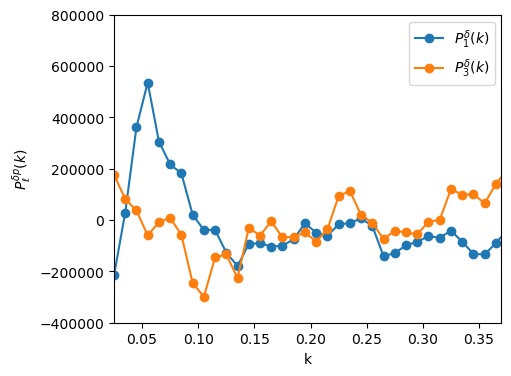

In [17]:
out_dir,wfkpc,Normc  = Pkest_Fun(kmin,kmax,nk,nx,ny,nz,xmin,xmax,ymin,ymax,zmin,zmax,
                                             rav ,decv ,zv ,nb,FKP,  
                                             ravR,decvR,zvR,nbR*D2R_ratio, 
                                             rav,decv,zv,vp,evp,nb,FKPv,   
                                             OmegaM,OmegaA,Hub,sigv,
                                             Bulk_vel,'crs',PS_multi,Output_dir+'ExampData_crs',
                                             wv,wvR,wv)

# make some plots:
psfile=np.loadtxt(Output_dir+'ExampData_crs');
k =psfile[:,1] ; p1=psfile[:,3] ; p3=psfile[:,5]
plt.figure(9,figsize=(5,4))
plt.plot(k,k*p1,marker='o',label='$P^{\delta}_1(k)$'); 
plt.plot(k,k*p3,marker='o',label='$P^{\delta}_3(k)$');
plt.xlim(0.025,0.37);plt.legend(fontsize=10);plt.ylim(-0.4*10**6,0.8*10**6); 
plt.legend(fontsize=10)
plt.ylabel(r"$P^{\delta p}_{\ell}(k)$",fontsize=10);plt.xlabel("k",fontsize=10);plt.tick_params( labelsize =10); 

<font color='brown'><font size="4.9">Section 5. Measuring the Power Spectrum of Randoms </font></font>


  Random-PS= mom 



/var/folders/f1/cbt1fjn100xdvvn071mfnxlh0000gn/T/ipykernel_97757/2714496192.py:18: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0.0,0.37);plt.legend(fontsize=10);#plt.ylim(-500,1800);


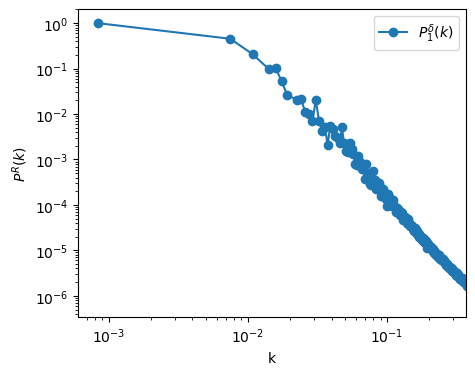

In [18]:
# grid and k-bin for randoms:
kminr,kmaxr,nkr = 0.0,0.5,300
nxr,nyr,nzr     = 400,400,400 
xminr,xmaxr     = -400. ,400. 
yminr,ymaxr     = -400. ,400.
zminr,zmaxr     = -400. ,400.

out_dir,wfkpvR       = PkestR_Fun(kminr,kmaxr,nkr,nxr,nyr,nzr,xminr,xmaxr,yminr,ymaxr,zminr,zmaxr, 
                                              ravR,decvR, zvR ,evpR,nbR*D2R_ratio,FKPv,
                                              OmegaM,OmegaA,Hub,sigv,'mom',Output_dir+'ExampRand_mom',
                                              wvR)
# make some plots:
psfile=np.loadtxt(Output_dir+'ExampRand_mom');
k =psfile[:,1] ; p=psfile[:,2]
plt.figure(9,figsize=(5,4))
plt.xscale('log'); plt.yscale('log')
plt.plot(k,p,marker='o',label='$P^{\delta}_1(k)$'); 
plt.xlim(0.0,0.37);plt.legend(fontsize=10);#plt.ylim(-500,1800); 
plt.legend(fontsize=10)
plt.ylabel(r"$P^{R}(k)$",fontsize=10);plt.xlabel("k",fontsize=10);plt.tick_params( labelsize =10); 

\
\
<font color='brown'><font size="5.9">Part 3. The Window Function Covolution</font></font>

\
<font color='brown'><font size="4.9">Please refer to '2_WinConv.py' </font></font>

\
\
\
<font color='brown'><font size="6">########. The End ! ########</font></font>